In [1]:
import matplotlib.pyplot as plt

from sldl import SignLanguageDataset

from sign_language_tools.player import VideoPlayer
from sign_language_tools.pose.mediapipe.edges import UPPER_POSE_EDGES, HAND_EDGES
from sign_language_tools.annotations.visualization.segments import plot_segments

from slp.targets.loading import load_continuous_target

In [2]:
root = "F:/datasets/sign-language/lsfb-cont"
shards_url = f"file:{root}/shards/annotated/" + "shard_000005.tar"

In [3]:
dataset = SignLanguageDataset(
    shards_url=shards_url,
    use_windows=True,
    window_size=3200,
    window_stride=2560,
    max_empty_windows=0,
    targets={
        'temporal-segmentation': load_continuous_target('temporal-segmentation'),
        'temporal-segmentation-noise-low': load_continuous_target('temporal-segmentation', 'low-noise'),
        'temporal-segmentation-noise-medium': load_continuous_target('temporal-segmentation', 'medium-noise'),
        'temporal-segmentation-noise-high': load_continuous_target('temporal-segmentation', 'high-noise'),
        'temporal-offsets': load_continuous_target('temporal-offsets'),
        'bio-tags': load_continuous_target('bio-tags'),
        'boundaries-segmentation': load_continuous_target('boundaries-segmentation'),
        'boundaries-offsets': load_continuous_target('boundaries-offsets'),
    },
    precompute_targets=True,
    load_videos=True,
    video_path=f"{root}/videos.tar",
    video_index_path=f"{root}/videos.tar.index.json",
    show_loading_progress=True,
)

len(dataset)

Loading dataset [file:F:/datasets/sign-language/lsfb-cont/shards/annotated/shard_000005.tar]...


Loading samples: 63 samples [00:01, 58.04 samples/s]


Loaded 63 samples.
Building windows of size 3200 with stride 2560...
Converted 63 samples to 494 windowed samples.
Removed 52 empty samples. There are 442 final samples.
Precomputing targets...
Target precomputed.


442

In [4]:
sample = dataset[159]
print(sample.keys())

segments = sample['annotations']['both_hands'].loc[:,['start_frame', 'end_frame']].values
labels = sample['annotations']['both_hands']['lemma'].to_list()
print(segments.shape)

dict_keys(['id', 'poses', 'annotations', 'n_frames', '__key__', 'start', 'end', 'targets', 'video', 'window_id'])
(135, 2)


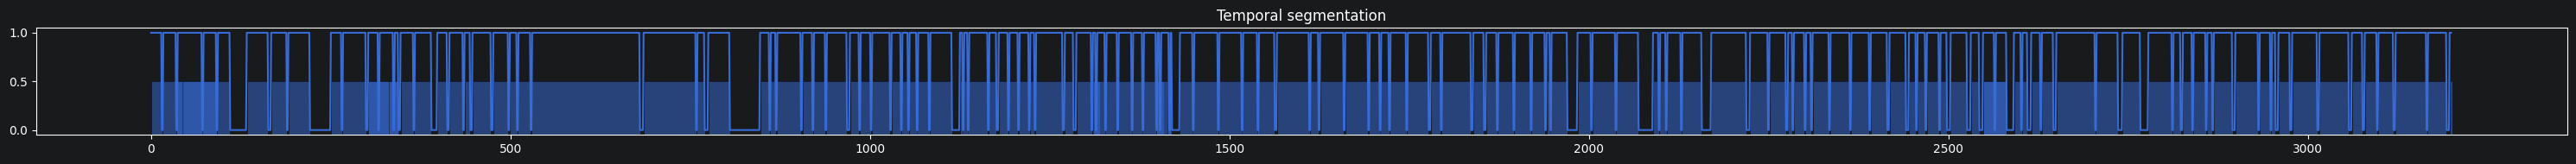

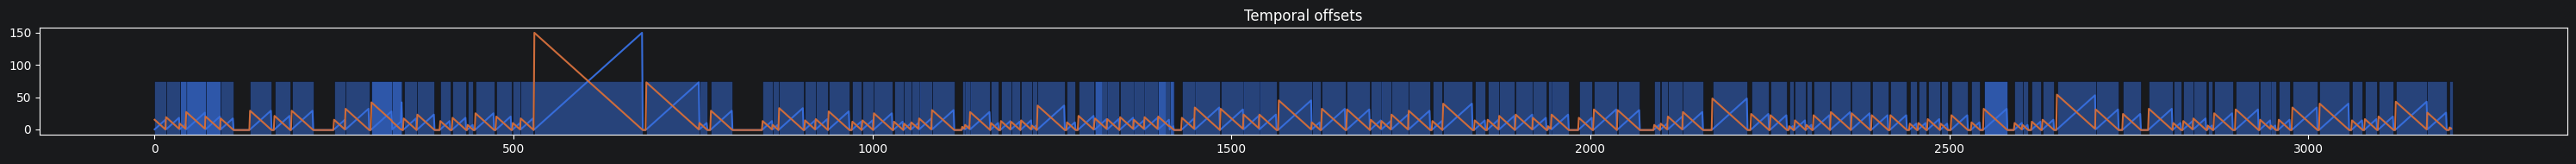

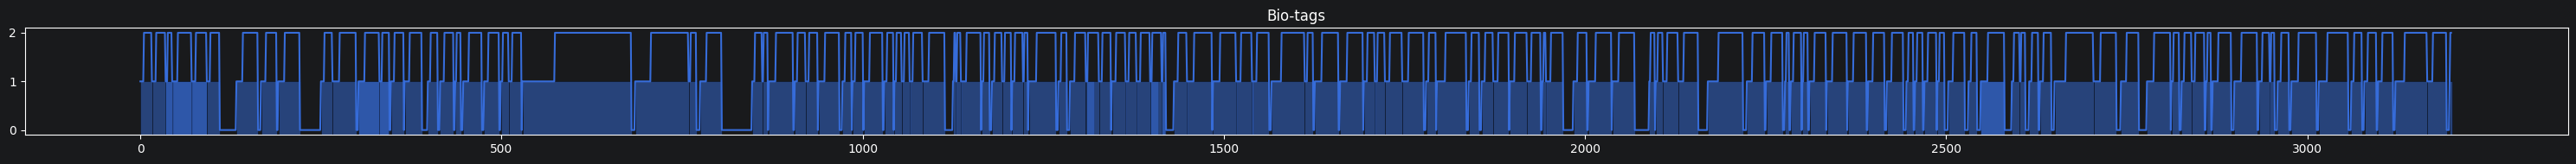

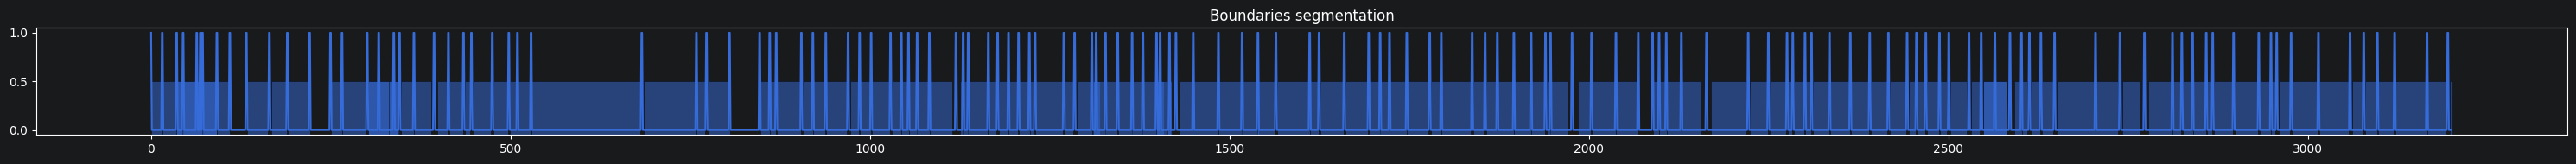

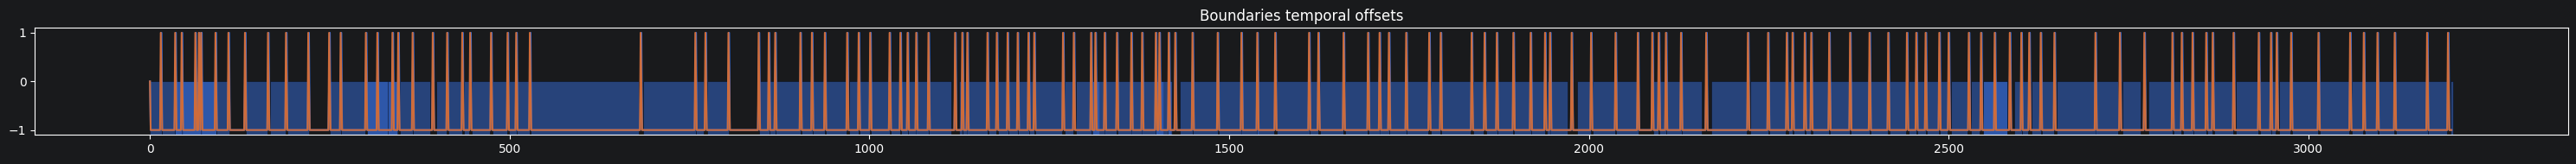

In [5]:
plt.figure(figsize=(30, 2))
plt.title("Temporal segmentation")
plot_segments(segments)
plt.plot(sample['targets']['temporal-segmentation'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(30, 2))
plt.title("Temporal offsets")
plot_segments(segments)
plt.plot(sample['targets']['temporal-offsets'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(30, 2))
plt.title("Bio-tags")
plot_segments(segments)
plt.plot(sample['targets']['bio-tags'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(30, 2))
plt.title("Boundaries segmentation")
plot_segments(segments)
plt.plot(sample['targets']['boundaries-segmentation'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(30, 2))
plt.title("Boundaries temporal offsets")
plot_segments(segments)
plt.plot(sample['targets']['boundaries-offsets'])
plt.tight_layout()
plt.show()

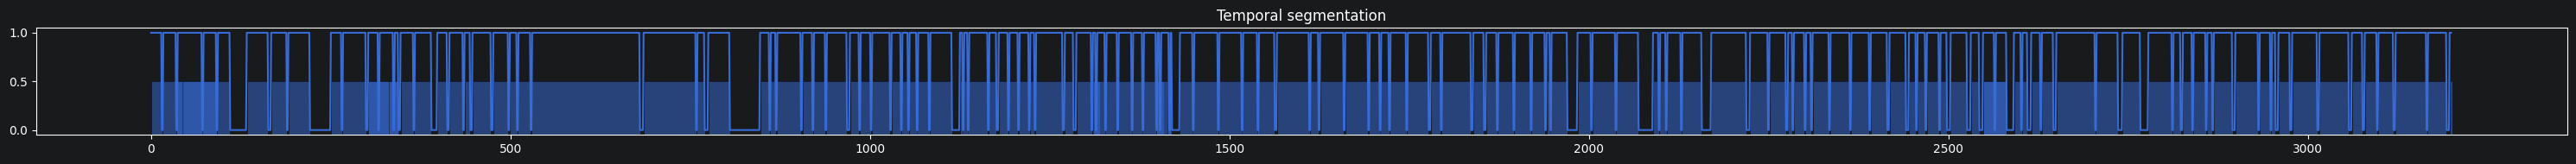

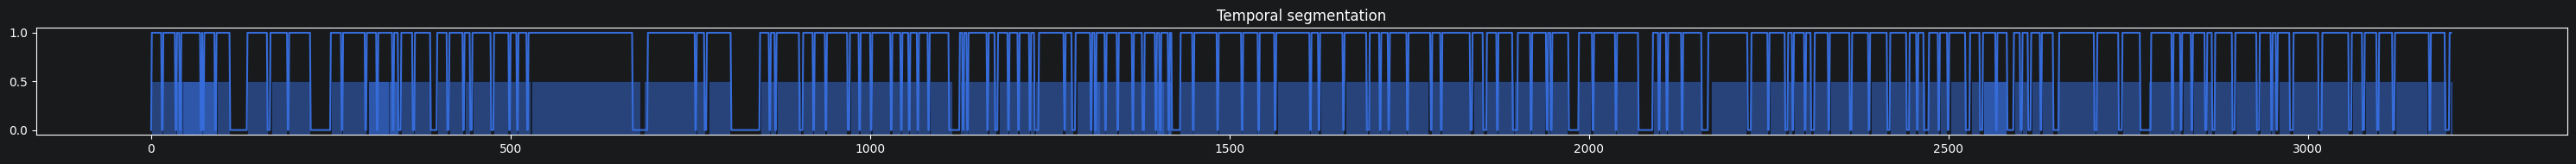

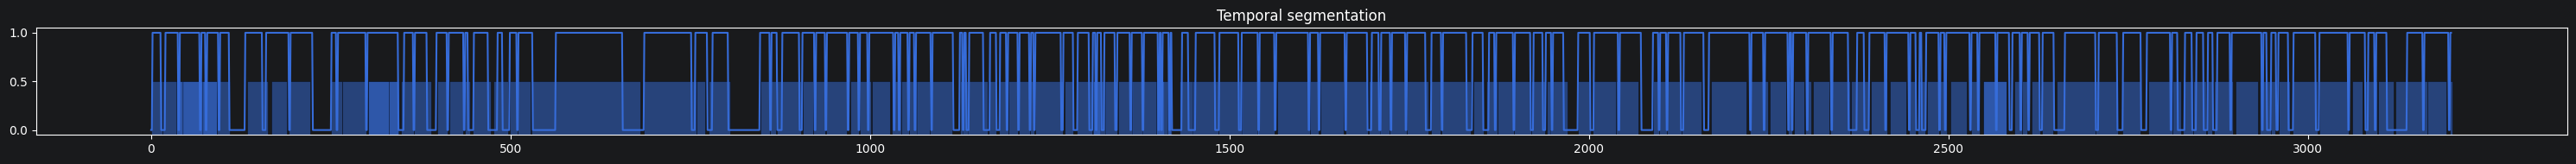

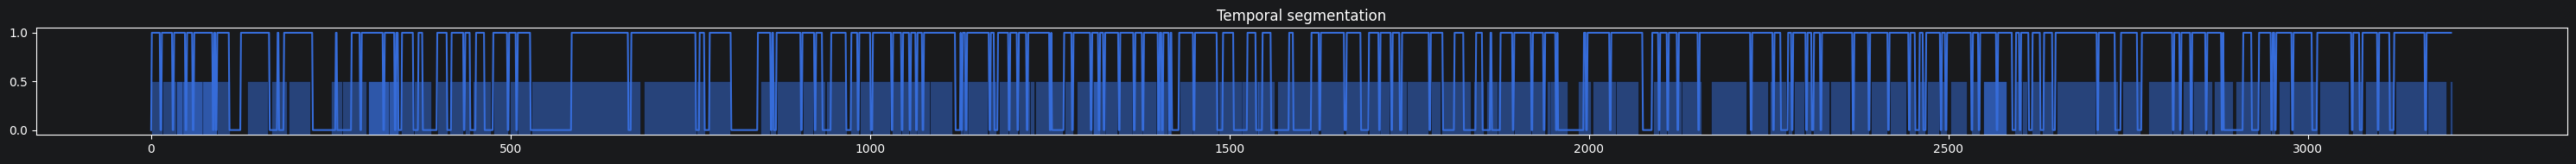

In [10]:
plt.figure(figsize=(30, 2))
plt.title("Temporal segmentation")
plot_segments(segments)
plt.plot(sample['targets']['temporal-segmentation'])
plt.tight_layout()
plt.show()
# plt.savefig('example.pdf')

plt.figure(figsize=(30, 2))
plt.title("Temporal segmentation")
plot_segments(segments)
plt.plot(sample['targets']['temporal-segmentation-noise-low'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(30, 2))
plt.title("Temporal segmentation")
plot_segments(segments)
plt.plot(sample['targets']['temporal-segmentation-noise-medium'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(30, 2))
plt.title("Temporal segmentation")
plot_segments(segments)
plt.plot(sample['targets']['temporal-segmentation-noise-high'])
plt.tight_layout()
plt.show()

In [7]:
player = VideoPlayer()
player.attach_video_tensor(sample['video'].permute(0, 2, 3, 1), fps=50, name='video')
player.attach_poses(sample['poses']['upper_pose'], UPPER_POSE_EDGES, parent_name='video')
player.attach_poses(sample['poses']['left_hand'], HAND_EDGES, edge_color=(255, 0, 0), parent_name='video')
player.attach_poses(sample['poses']['right_hand'], HAND_EDGES, edge_color=(0, 0, 255), parent_name='video')
player.attach_segments(segments, unit='frame', fps=50, labels=labels, x_lim=(0, 1300), filled=True, background_color=(255, 255, 255), text_color=(0, 0, 0), segment_color=(50, 255, 50), ticks_color=(0, 0, 0))
player.play(speed=0.5)

In [8]:
sample['annotations']['both_hands']

,start_ms,end_ms,gloss,start_frame,end_frame,lemma,sign_type,specifier,variation
370,0,287,cafe(confusion avec compote),0,15,cafe,lexical,None,(confusion avec compote)
371,306,669,peu.petit,16,35,peu.petit,lexical,None,None
372,669,1740,ds,35,91,None,depictive,None,None
373,669,841,ds:verser eau,35,44,None,depictive,verser eau,None
374,841,1358,chaud,44,71,chaud,lexical,None,None
...,...,...,...,...,...,...,...,...,...
500,58870,59176,c-est-tout,3079,3095,c-est-tout,lexical,None,None
501,59234,59616,reste,3098,3118,reste,lexical,None,None
502,59693,60515,grand.hauteur,3122,3165,grand.hauteur,lexical,None,None
503,60534,61031,palm-up,3166,3192,None,palm-up,None,None


In [9]:
sample['targets']['temporal-segmentation']

tensor([1, 1, 1,  ..., 1, 1, 1])